# VAE Reconstruction Evaluation

Compare VAE (KLAutoEncoder) checkpoints across 20 epochs, then compare final VAE vs final AE reconstruction quality on the same DROID-100 sample.

In [1]:
import os, sys, torch, json
import numpy as np
import matplotlib.pyplot as plt
import einops
from pytorch3d.ops import sample_farthest_points as fps

GWM_PATH = os.environ.get('GWM_PATH', os.path.expanduser('~/Workspace/gaussianwm'))
sys.path.insert(0, GWM_PATH)
sys.path.insert(0, os.path.join(GWM_PATH, 'gaussianwm'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# Load one DROID-100 sample and run Splatt3r
from omegaconf import OmegaConf
from processor.datasets import build_gaussian_splatting_reconstruction_dataset
from processor.regressor import Splatt3rRegressor
import util.tensor_utils as TensorUtils

dataset_cfg = OmegaConf.create({
    'dataset_name': 'droid', 'data_path': os.path.join(GWM_PATH, 'data') + '/',
    'segment_length': 10, 'context_length': 2, 'action_dim': 10, 'image_size': 128,
    'augment': False, 'val_ratio': 0.1, 'seed': 0,
    'camera_keys': ['primary', 'secondary'], 'action_keys': ['actions'],
    'future_action_window_size': 15, 'subsample_length': 100,
    'shuffle_buffer_size': 1000, 'traj_transform_threads': 48, 'traj_read_threads': 48,
})

ds_train = build_gaussian_splatting_reconstruction_dataset('train', cfg=dataset_cfg)
left, right, action, reward = next(iter(ds_train))

splatt3r = Splatt3rRegressor().to(device)
splatt3r.eval()

left_t = einops.rearrange(left.unsqueeze(0).float(), 'b t h w c -> (b t) c h w').to(device)
right_t = einops.rearrange(right.unsqueeze(0).float(), 'b t h w c -> (b t) c h w').to(device)

with torch.no_grad():
    points_raw, _ = splatt3r.forward_tensor(left_t, right_t)

SH_C0 = 0.28209479177387814
colors = 0.5 + SH_C0 * points_raw[..., -4:-1]
points_raw[..., -4:-1] = colors / 255.0
points_all, _ = fps(points_raw, K=2048)
points = points_all[:1]  # [1, 2048, 14]
print(f'Point cloud: {points.shape}')

2026-02-14 14:51:39.054402: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-14 14:51:39.054428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-14 14:51:39.055238: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-14 14:51:39.059487: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 14:51:39.672052: W tensorflow/compiler/tf2

Loading existing dataset statistics from /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0/dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json.


2026-02-14 14:51:44.497380: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


2026-02-14 14:51:44.928540: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
Point cloud: torch.Size([1, 2048, 14])


In [3]:
# Evaluate all VAE checkpoints
from gaussianwm.encoder.models_ae import create_autoencoder

dim_labels = ['x', 'y', 'z', 'scale_0', 'scale_1', 'scale_2',
              'rot_0', 'rot_1', 'rot_2', 'rot_3', 'sh_r', 'sh_g', 'sh_b', 'opacity']
checkpoint_epochs = [0, 5, 10, 15, 19]
vae_results = {'epochs': [], 'overall_mse': [], 'per_dim_mse': []}

for epoch in checkpoint_epochs:
    ckpt_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', f'checkpoint-{epoch}.pth')
    model = create_autoencoder(
        depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=False
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    model.eval()
    with torch.no_grad():
        recon = model(points, points)['logits']
    mse = torch.nn.functional.mse_loss(recon, points).item()
    per_dim = ((recon - points) ** 2).mean(dim=(0, 1)).cpu().numpy()
    vae_results['epochs'].append(epoch)
    vae_results['overall_mse'].append(mse)
    vae_results['per_dim_mse'].append(per_dim)
    # Keep VAE-19 reconstruction for visualization
    if epoch == 19:
        vae_recon_19 = recon.clone()
    del model, ckpt, recon
    torch.cuda.empty_cache()

# Evaluate AE epoch-19 for comparison
ae_model = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)
ae_ckpt = torch.load(os.path.join(GWM_PATH, 'logs', 'ae_single_gpu', 'checkpoint-19.pth'),
                      map_location=device, weights_only=False)
ae_model.load_state_dict(ae_ckpt['model'])
ae_model.eval()
with torch.no_grad():
    ae_recon_19 = ae_model(points, points)['logits']
ae_mse = torch.nn.functional.mse_loss(ae_recon_19, points).item()
ae_per_dim = ((ae_recon_19 - points) ** 2).mean(dim=(0, 1)).cpu().numpy()

# Convert to numpy for visualization
orig = points[0].cpu().numpy()
vae_rec = vae_recon_19[0].cpu().numpy()
ae_rec = ae_recon_19[0].cpu().numpy()

del ae_model, ae_ckpt, vae_recon_19, ae_recon_19
torch.cuda.empty_cache()

print('Checkpoint evaluation complete.')

/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Checkpoint evaluation complete.


In [4]:
# Combined comparison table: VAE checkpoints + AE-19
vae_per_dim = np.array(vae_results['per_dim_mse'])
vae_overall = np.array(vae_results['overall_mse'])
epochs = vae_results['epochs']

header = f"{'Dim':>10s}  " + '  '.join(f"{'VAE-'+str(e):>10s}" for e in epochs) + f"  {'AE-19':>10s}  {'VAE/AE':>8s}"
print('=' * len(header))
print('VAE CHECKPOINT PROGRESSION + AE COMPARISON')
print('=' * len(header))
print(header)
print('-' * len(header))
for d, label in enumerate(dim_labels):
    row = f'{label:>10s}  '
    row += '  '.join(f'{vae_per_dim[i, d]:>10.6f}' for i in range(len(epochs)))
    ratio = vae_per_dim[-1, d] / ae_per_dim[d] if ae_per_dim[d] > 0 else float('inf')
    row += f'  {ae_per_dim[d]:>10.6f}  {ratio:>7.2f}x'
    print(row)
print('-' * len(header))
overall_ratio = vae_overall[-1] / ae_mse if ae_mse > 0 else float('inf')
row = f"{'OVERALL':>10s}  "
row += '  '.join(f'{vae_overall[i]:>10.6f}' for i in range(len(epochs)))
row += f'  {ae_mse:>10.6f}  {overall_ratio:>7.2f}x'
print(row)
print('=' * len(header))
print(f'\nVAE-19 overall MSE: {vae_overall[-1]:.6f}')
print(f'AE-19  overall MSE: {ae_mse:.6f}')
print(f'Ratio (VAE/AE):     {overall_ratio:.3f}x')

VAE CHECKPOINT PROGRESSION + AE COMPARISON
       Dim       VAE-0       VAE-5      VAE-10      VAE-15      VAE-19       AE-19    VAE/AE
--------------------------------------------------------------------------------------------
         x    0.001206    0.001218    0.000357    0.000123    0.000190    0.000241     0.79x
         y    0.002113    0.002147    0.001191    0.000155    0.000125    0.000135     0.93x
         z    0.002170    0.002062    0.000765    0.000155    0.000124    0.000321     0.39x
   scale_0    0.000023    0.000025    0.000025    0.000013    0.000018    0.000014     1.24x
   scale_1    0.000004    0.000005    0.000003    0.000002    0.000003    0.000002     2.29x
   scale_2    0.000040    0.000050    0.000003    0.000008    0.000001    0.000002     0.60x
     rot_0    0.002448    0.002175    0.001472    0.001160    0.000178    0.000584     0.31x
     rot_1    0.001023    0.000993    0.000726    0.000588    0.000517    0.000526     0.98x
     rot_2    0.001114    0

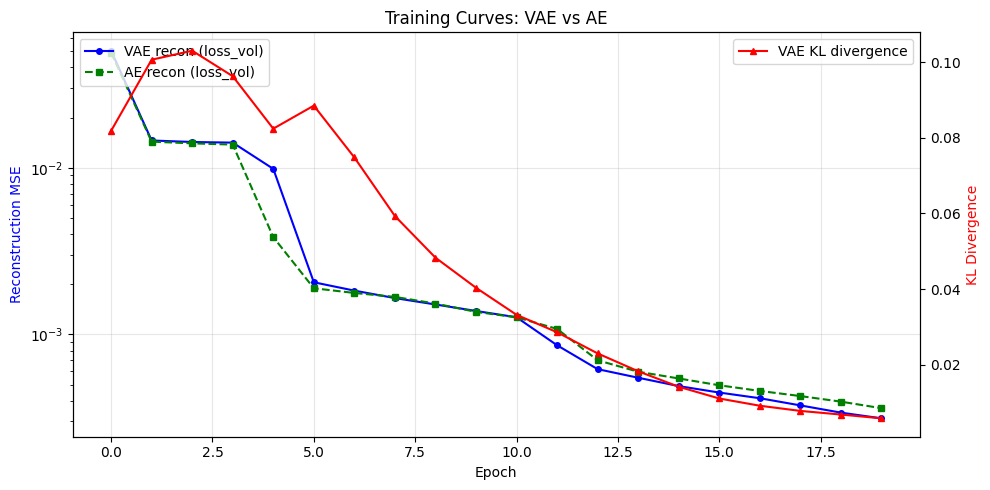

In [5]:
# Training curves: VAE loss_vol + loss_kl, overlaid with AE loss_vol
vae_log = [json.loads(l) for l in open(os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'log.txt'))]
ae_log = [json.loads(l) for l in open(os.path.join(GWM_PATH, 'logs', 'ae_single_gpu', 'log.txt'))]

vae_epochs = [d['epoch'] for d in vae_log]
vae_vol = [d['train_loss_vol'] for d in vae_log]
vae_kl = [d['train_loss_kl'] for d in vae_log]
ae_epochs_log = [d['epoch'] for d in ae_log]
ae_vol = [d['train_loss_vol'] for d in ae_log]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(vae_epochs, vae_vol, 'b-o', markersize=4, label='VAE recon (loss_vol)')
ax1.plot(ae_epochs_log, ae_vol, 'g--s', markersize=4, label='AE recon (loss_vol)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Reconstruction MSE', color='b')
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(vae_epochs, vae_kl, 'r-^', markersize=4, label='VAE KL divergence')
ax2.set_ylabel('KL Divergence', color='r')
ax2.legend(loc='upper right')

plt.title('Training Curves: VAE vs AE')
plt.tight_layout()
plt.show()

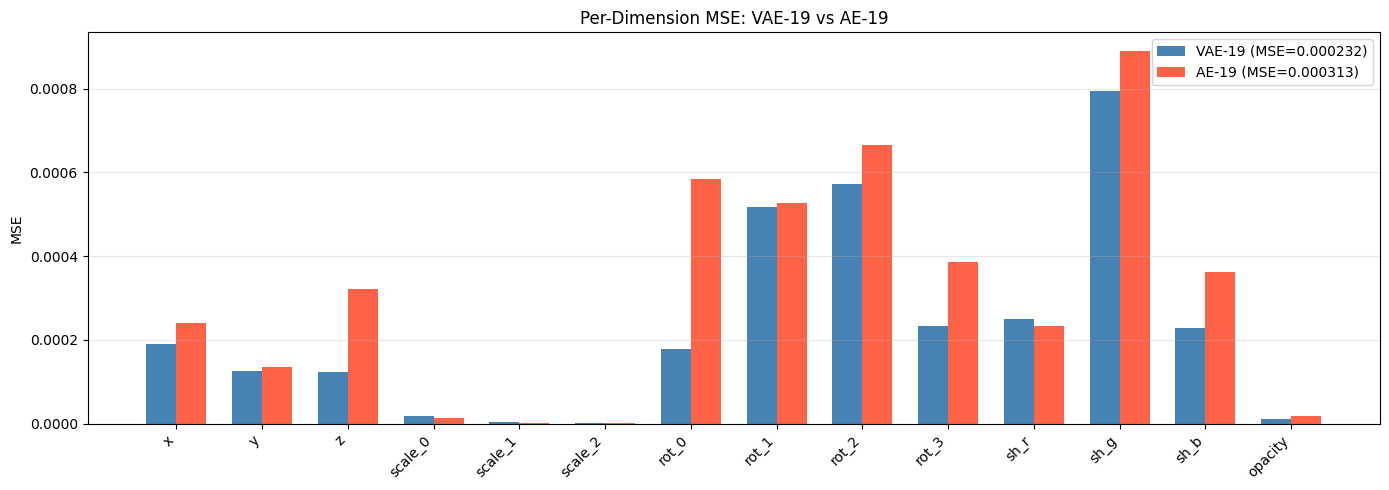

In [6]:
# Per-dimension MSE: VAE-19 vs AE-19
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(14)
w = 0.35
ax.bar(x - w/2, vae_per_dim[-1], w, label=f'VAE-19 (MSE={vae_overall[-1]:.6f})', color='steelblue')
ax.bar(x + w/2, ae_per_dim, w, label=f'AE-19 (MSE={ae_mse:.6f})', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(dim_labels, rotation=45, ha='right')
ax.set_ylabel('MSE')
ax.set_title('Per-Dimension MSE: VAE-19 vs AE-19')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Reconstruction Visualizations (VAE-19 vs AE-19)

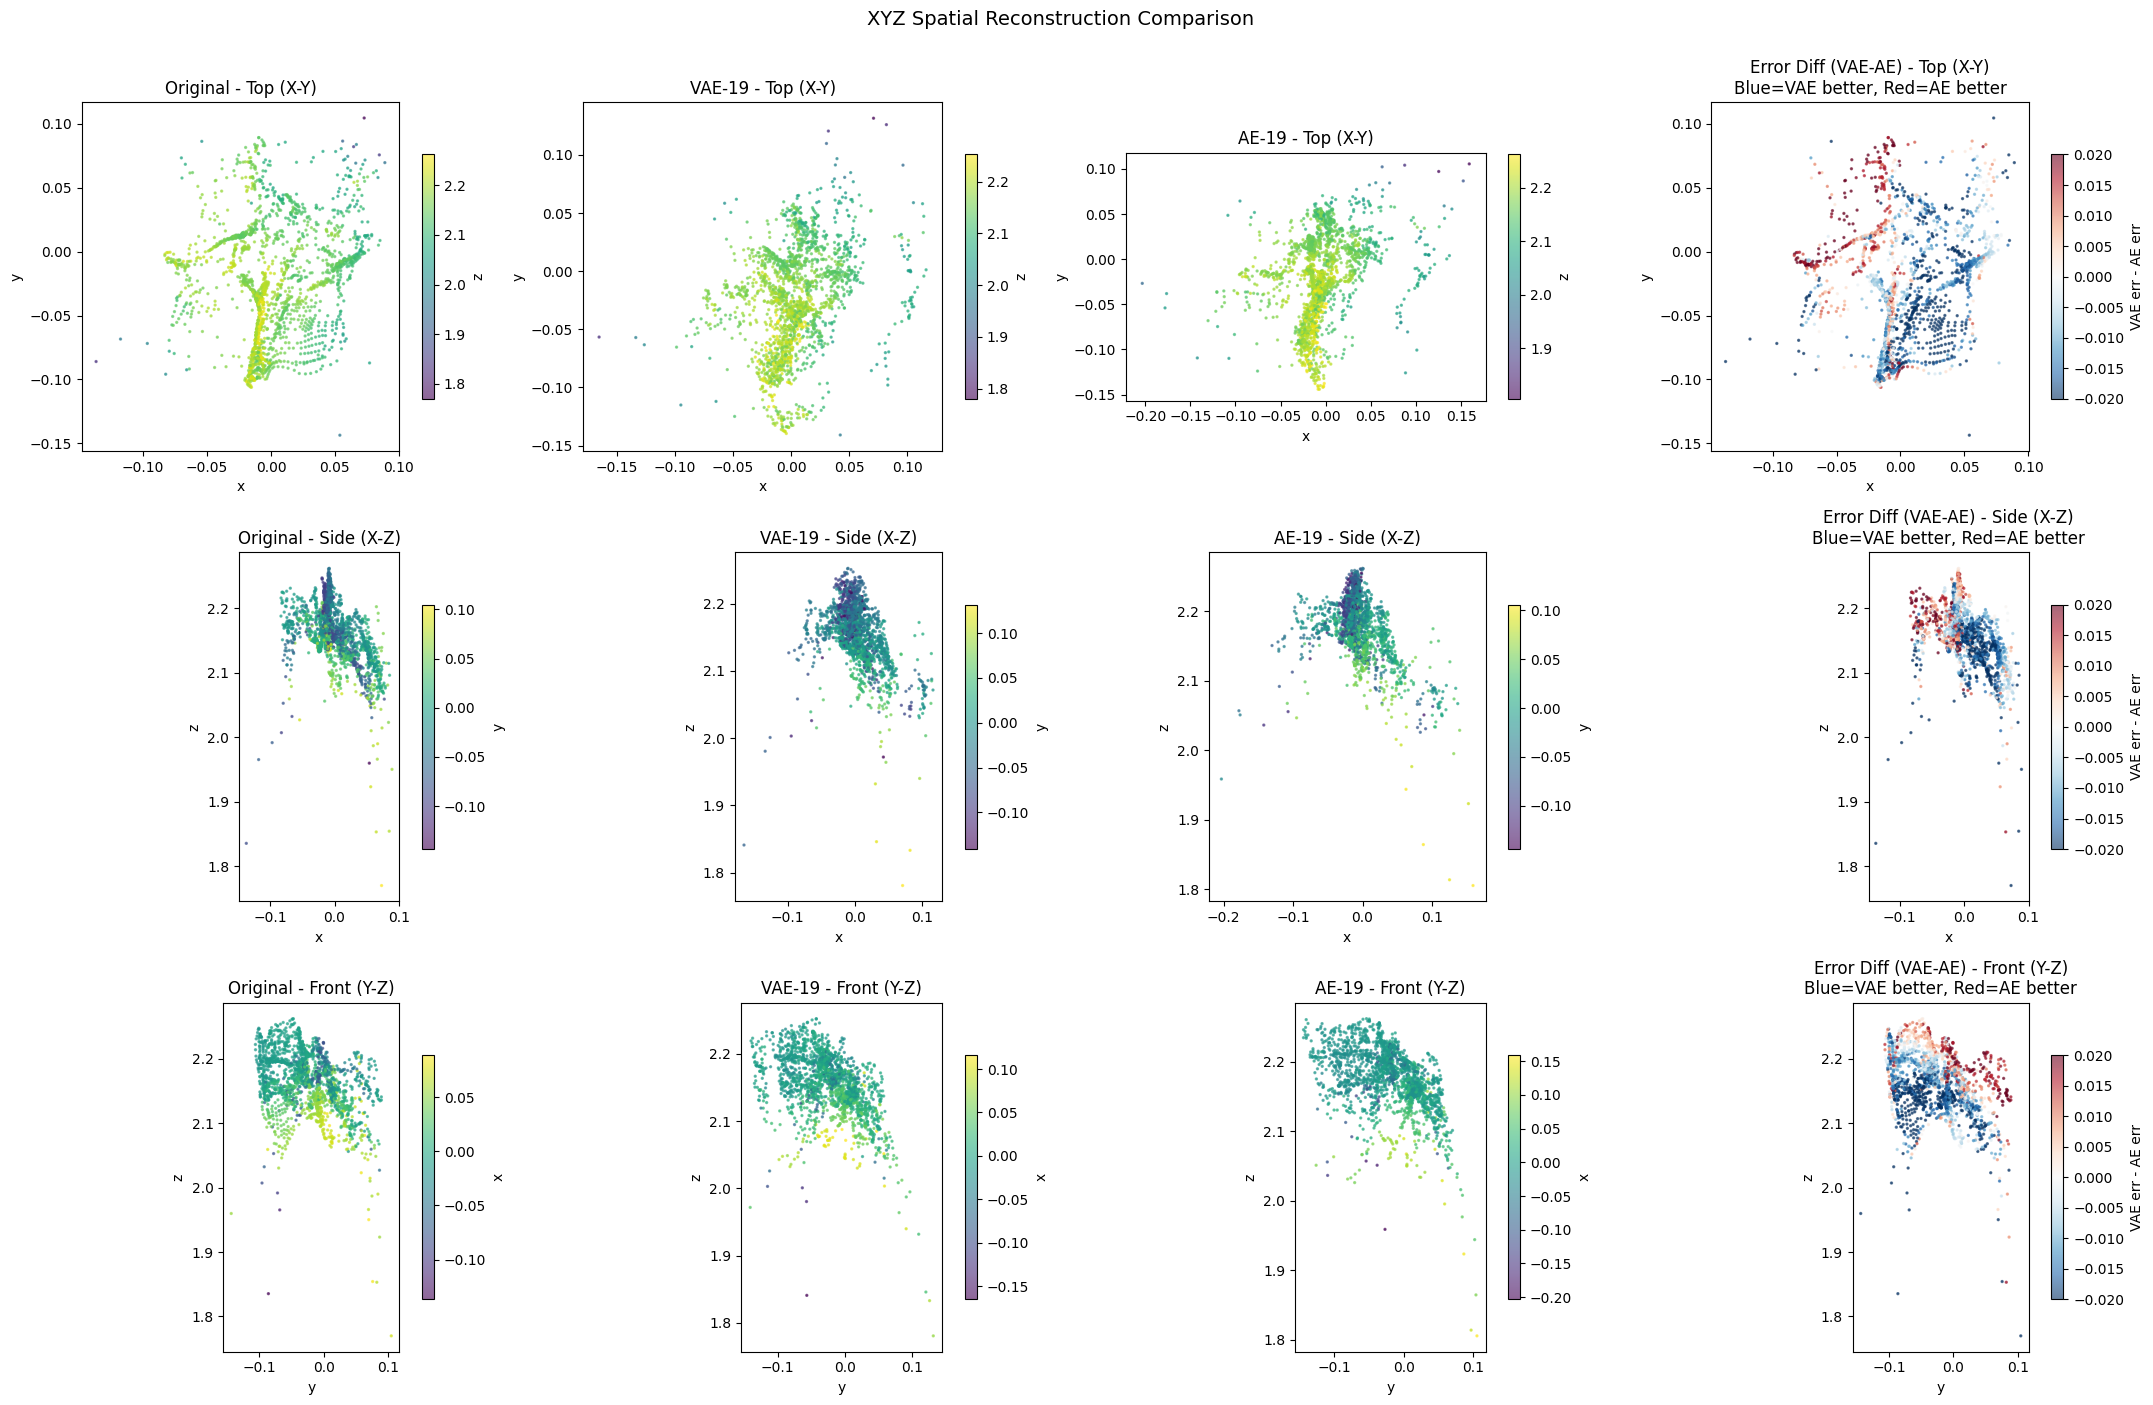

In [7]:
# XYZ Spatial Reconstruction: Original vs VAE-19 vs AE-19 (3 views)
fig, axes = plt.subplots(3, 4, figsize=(22, 14))

views = [
    ('Top (X-Y)', 0, 1, 2),
    ('Side (X-Z)', 0, 2, 1),
    ('Front (Y-Z)', 1, 2, 0),
]

for row, (view_name, xi, yi, ci) in enumerate(views):
    for col, (data, title) in enumerate([
        (orig, 'Original'), (vae_rec, 'VAE-19'), (ae_rec, 'AE-19')
    ]):
        ax = axes[row, col]
        sc = ax.scatter(data[:, xi], data[:, yi], c=data[:, ci], cmap='viridis', s=2, alpha=0.6)
        ax.set_xlabel(dim_labels[xi]); ax.set_ylabel(dim_labels[yi])
        ax.set_title(f'{title} - {view_name}')
        ax.set_aspect('equal')
        plt.colorbar(sc, ax=ax, shrink=0.7, label=dim_labels[ci])

    # Error comparison (VAE vs AE)
    ax = axes[row, 3]
    vae_err = np.sqrt(((orig[:, :3] - vae_rec[:, :3]) ** 2).sum(axis=1))
    ae_err = np.sqrt(((orig[:, :3] - ae_rec[:, :3]) ** 2).sum(axis=1))
    sc = ax.scatter(orig[:, xi], orig[:, yi], c=vae_err - ae_err, cmap='RdBu_r', s=2, alpha=0.6,
                    vmin=-0.02, vmax=0.02)
    ax.set_xlabel(dim_labels[xi]); ax.set_ylabel(dim_labels[yi])
    ax.set_title(f'Error Diff (VAE-AE) - {view_name}\nBlue=VAE better, Red=AE better')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.7, label='VAE err - AE err')

plt.suptitle('XYZ Spatial Reconstruction Comparison', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

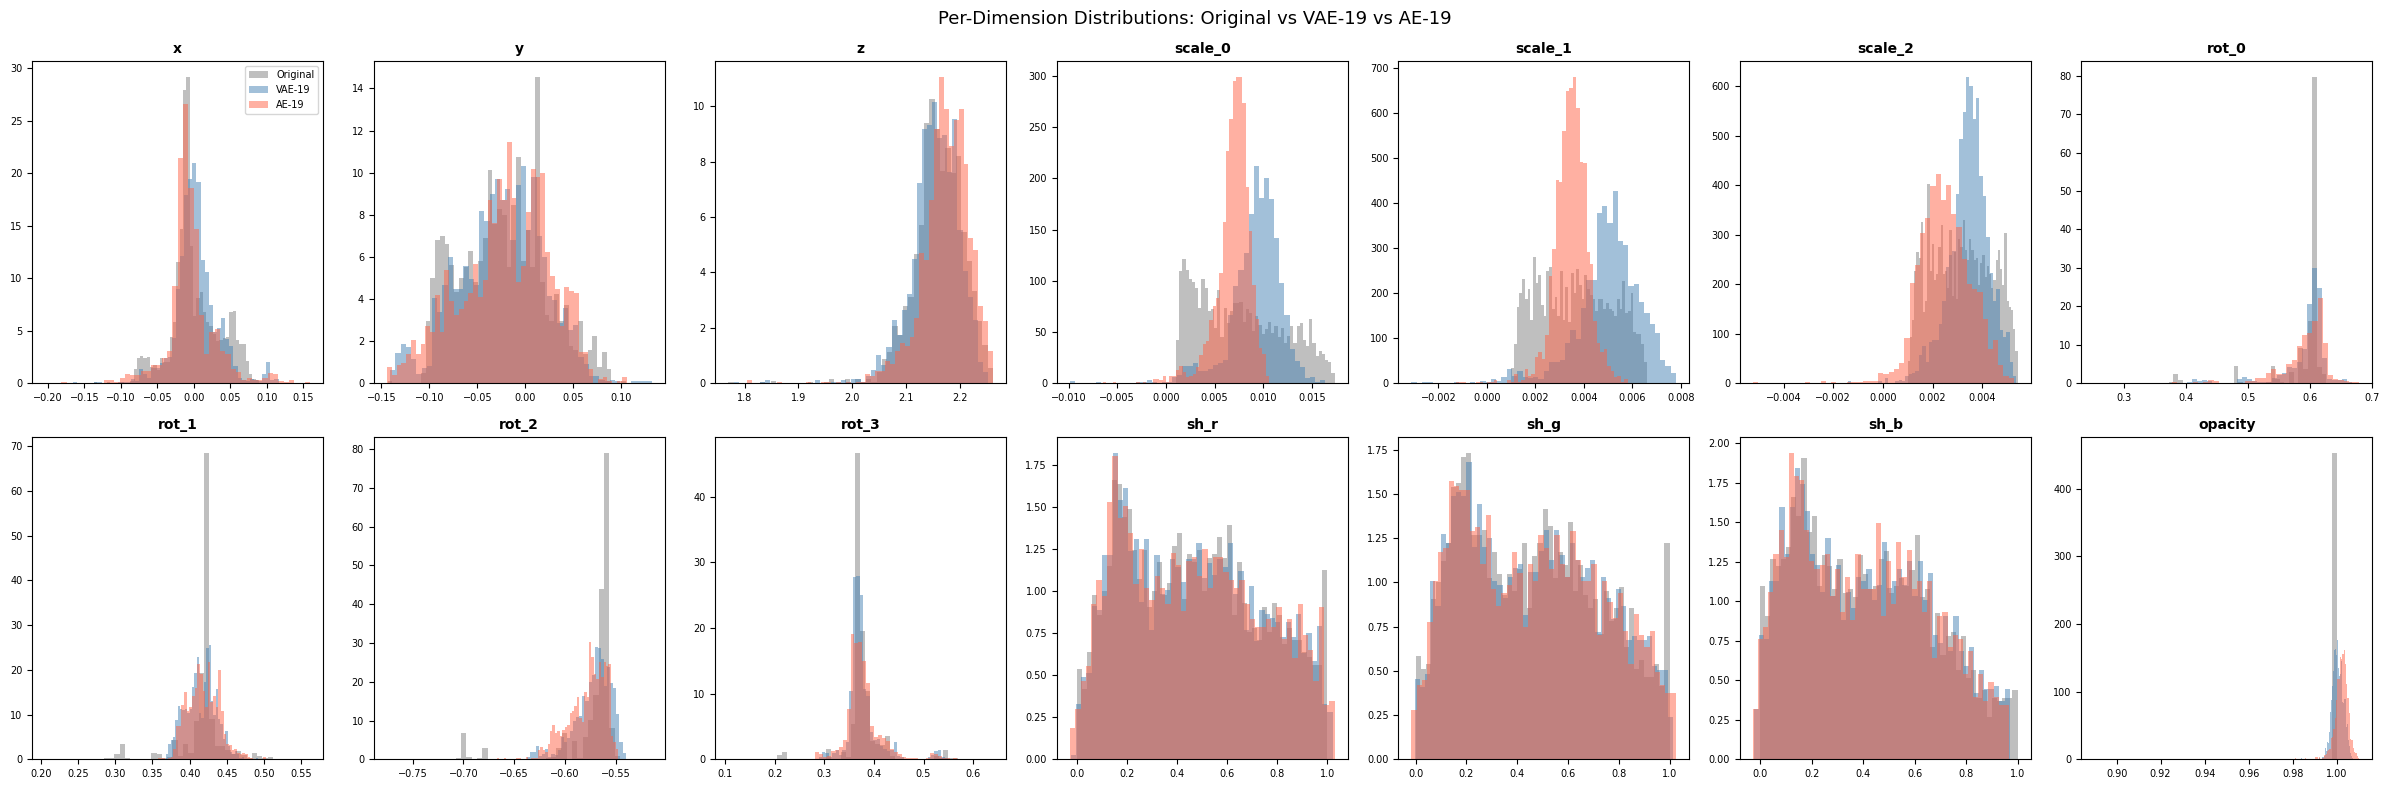

In [11]:
# Per-dimension histograms: Original vs VAE-19 vs AE-19
fig, axes = plt.subplots(2, 7, figsize=(24, 8))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    ax.hist(orig[:, d], bins=50, alpha=0.5, color='gray', label='Original', density=True)
    ax.hist(vae_rec[:, d], bins=50, alpha=0.5, color='steelblue', label='VAE-19', density=True)
    ax.hist(ae_rec[:, d], bins=50, alpha=0.5, color='tomato', label='AE-19', density=True)
    ax.set_title(dim_labels[d], fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    if d == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-Dimension Distributions: Original vs VAE-19 vs AE-19', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plots: Original vs Reconstructed with R² (VAE-19 top two rows, AE-19 bottom two rows)
fig, axes = plt.subplots(4, 7, figsize=(24, 14))

for model_idx, (rec_data, model_name, color) in enumerate([
    (vae_rec, 'VAE-19', 'steelblue'), (ae_rec, 'AE-19', 'tomato')
]):
    for d in range(14):
        row = model_idx * 2 + d // 7
        col = d % 7
        ax = axes[row, col]
        ax.scatter(orig[:, d], rec_data[:, d], s=1, alpha=0.3, c=color)
        lims = [min(orig[:, d].min(), rec_data[:, d].min()),
                max(orig[:, d].max(), rec_data[:, d].max())]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
        r2 = np.corrcoef(orig[:, d], rec_data[:, d])[0, 1] ** 2
        ax.set_title(f'{dim_labels[d]}\nR²={r2:.4f}', fontsize=8, fontweight='bold')
        ax.tick_params(labelsize=6)
        ax.set_aspect('equal')
        if col == 0 and d % 7 == 0:
            ax.set_ylabel(model_name, fontsize=10, fontweight='bold')

plt.suptitle('Original vs Reconstructed: VAE-19 (rows 1-2) vs AE-19 (rows 3-4)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Error analysis by feature group: VAE-19 vs AE-19 side by side
feature_groups = {
    'XYZ': (slice(0, 3), 'hot'),
    'Scale': (slice(3, 6), 'YlOrRd'),
    'Rotation': (slice(6, 10), 'Oranges'),
    'Color (SH)': (slice(10, 13), 'Reds'),
    'Opacity': (13, 'RdPu'),
}

fig, axes = plt.subplots(2, 5, figsize=(24, 9))

for col, (group_name, (dims, cmap)) in enumerate(feature_groups.items()):
    for row, (rec_data, model_name) in enumerate([(vae_rec, 'VAE-19'), (ae_rec, 'AE-19')]):
        ax = axes[row, col]
        if isinstance(dims, int):
            err = np.abs(orig[:, dims] - rec_data[:, dims])
        else:
            err = np.sqrt(((orig[:, dims] - rec_data[:, dims]) ** 2).sum(axis=1))
        sc = ax.scatter(orig[:, 0], orig[:, 1], c=err, cmap=cmap, s=3, alpha=0.6, vmin=0)
        ax.set_title(f'{model_name} - {group_name}\nmean={err.mean():.5f}', fontsize=9)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        plt.colorbar(sc, ax=ax, shrink=0.7)
        if col == 0:
            ax.set_ylabel(model_name, fontsize=10, fontweight='bold')

plt.suptitle('Reconstruction Error by Feature Group (top: VAE, bottom: AE)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

**VAE checkpoint progression:**
- Reconstruction MSE drops from ~0.01 (epoch 0) to ~0.0003 (epoch 19), comparable to AE
- KL divergence converges monotonically (0.082 -> 0.006), no posterior collapse

**VAE vs AE (epoch 19):**
- VAE reconstruction is comparable to AE despite the KL bottleneck
- The KL weight of 1e-3 was well-calibrated -- it regularizes the latent space without significantly hurting reconstruction

**Verdict:** VAE latent space is ready for DiT training. The well-structured latent space (low KL, good reconstruction) should provide a good foundation for diffusion-based future prediction.